# Chapter 27 - Microcontroller Programming and Deployment
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov - eCampus University, Italy**

This notebook accompanies Chapter 27. No physical board is required for the four core exercises. The same numerical functions generate the chapter figures and archived CSV files.

**Direct Colab link:** https://colab.research.google.com/drive/1NQq9G_glVb8zREp844ymiTG6IR43WzXA

### Learning path
1. Treat board selection as a resource and interface feasibility problem.
2. Compare a non-preemptive fixed-order dispatcher with a bounded-step deadline-first dispatcher using separate periodic jobs.
3. Learn an agreement-analysis workflow from explicitly synthetic paired values, then replace them with raw logs for a real reproduction.
4. Compile a nonlinear function into quantized lookup tables and identify the accuracy-memory Pareto frontier.

> **Data-status statement.** Exercise 27.3 uses a deterministic pedagogical dataset constrained by the public LUT-KAN validation bounds. It is not a reproduction of the original physical experiment and must not be cited as raw hardware evidence.

In [1]:
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
print("Python", sys.version.split()[0])
print("NumPy", np.__version__, "pandas", pd.__version__)

Python 3.12.3
NumPy 2.3.5 pandas 2.2.3


### Executable core
The next cell is generated from `chapter27_core.py`. The archive build script and the book figures use the same source file.

In [2]:
"""Single source of truth for Chapter 27 numerical exercises and figures.

The notebook is generated from this module. The static book figures and CSV files
are produced by generate_figures.py, which imports the same functions. This avoids
maintaining a separate illustrative model for the PDF.
"""
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COLAB_URL = "https://colab.research.google.com/drive/1NQq9G_glVb8zREp844ymiTG6IR43WzXA"

# Tolerance for floating-point job-timing comparisons in the Exercise 27.2
# scheduler simulation (all times in milliseconds). 1e-12 ms is tighter than
# the double-precision rounding error that accumulates over a 5-second,
# several-hundred-job simulation (~1e-11 ms), which produced spurious "missed"
# deadlines exactly at 100% offered demand. 1e-6 ms (1 nanosecond) is far
# larger than that rounding error yet far smaller than any timing difference
# the model treats as meaningful (the default quantum is 1 ms).
TIME_EPS_MS = 1e-6


def board_matrix() -> pd.DataFrame:
    """Return a pedagogical platform matrix, not a procurement specification.

    design_status distinguishes the Mega 2560 -- retained deliberately as a
    constraint-demonstration baseline -- from the five boards that represent
    current, actively recommended target classes. This is an explicit column
    rather than colour or row order so the distinction survives black-and-white
    printing and remains accessible.
    """
    return pd.DataFrame([
        # board, ISA, flash KiB, RAM KiB, MHz, wireless, role, scenario relative cost, design_status
        ("Arduino Mega 2560", "8-bit AVR", 256, 8, 16, "none", "legacy constrained baseline", 1.0, "constraint-demonstration baseline"),
        ("Raspberry Pi Pico", "Arm Cortex-M0+", 2048, 264, 133, "none", "accessible deterministic MCU", 1.1, "current representative target"),
        ("ESP32-C3", "32-bit RISC-V", 4096, 400, 160, "Wi-Fi/BLE", "low-cost connected RISC-V MCU", 1.2, "current representative target"),
        ("ESP32-S3", "Xtensa LX7", 8192, 512, 240, "Wi-Fi/BLE", "DSP/AI-oriented connected MCU", 1.6, "current representative target"),
        ("nRF52840", "Arm Cortex-M4F", 1024, 256, 64, "BLE/802.15.4", "low-power wireless reference", 1.7, "current representative target"),
        ("STM32L432KC", "Arm Cortex-M4F", 256, 64, 80, "external", "ultra-low-power control reference", 1.8, "current representative target"),
    ], columns=["board", "isa", "flash_kib", "ram_kib", "clock_mhz", "wireless", "role", "relative_cost", "design_status"])


def application_matrix() -> pd.DataFrame:
    """Pedagogical application scenarios for Exercise 27.1.

    "periodic sensing" is deliberately sized to fit the Arduino Mega 2560's
    5.6 KiB of usable RAM (8 KiB less the 30% reserve): a single sensor read
    and a serial print is a realistic fit at that scale, so the static
    screen shows a genuine boundary rather than "every application is
    rejected everywhere". "medium-scale LUT-compiled inference" is
    deliberately larger than the compact, single-function LUT actually
    deployed on the physical Mega 2560 in Section 27.4's LUT-KAN case study
    (a handful of bytes, not tens of KiB): the name signals that this
    scenario is a different, larger workload class, not a claim that the
    case study's own compact deployment is infeasible.
    """
    return pd.DataFrame([
        ("periodic sensing", 42, 4, 5.0, False, False),
        ("BLE environmental logger", 170, 42, 12.0, True, False),
        ("TLS telemetry node", 420, 120, 45.0, False, True),
        ("medium-scale LUT-compiled inference", 230, 58, 18.0, False, False),
        ("camera-class TinyML", 1500, 340, 90.0, False, True),
    ], columns=["application", "flash_need_kib", "ram_need_kib", "latency_limit_ms", "needs_ble", "needs_wifi"])


def resource_feasibility(flash_reserve: float = 0.20, ram_reserve: float = 0.30) -> pd.DataFrame:
    """Static resource-and-interface feasibility screen.

    This checks only flash headroom, RAM headroom, and required-radio presence.
    application_matrix() also carries latency_limit_ms, and board_matrix() carries
    clock_mhz and relative_cost, but neither feeds into the returned boolean: this
    function does not model execution time, energy, thermal behaviour, or economic
    cost. The result column is named static_feasible (not "feasible") so that
    passing this screen is never mistaken for a complete board-selection decision.
    """
    boards = board_matrix().copy()
    apps = application_matrix().copy()
    boards["usable_flash_kib"] = boards.flash_kib * (1.0 - flash_reserve)
    boards["usable_ram_kib"] = boards.ram_kib * (1.0 - ram_reserve)
    rows = []
    for _, a in apps.iterrows():
        for _, b in boards.iterrows():
            radio_ok = (not a.needs_ble or "BLE" in b.wireless) and (not a.needs_wifi or "Wi-Fi" in b.wireless)
            flash_headroom = b.usable_flash_kib - a.flash_need_kib
            ram_headroom = b.usable_ram_kib - a.ram_need_kib
            rows.append({
                "application": a.application,
                "board": b.board,
                "flash_headroom_kib": flash_headroom,
                "ram_headroom_kib": ram_headroom,
                "radio_ok": radio_ok,
                "static_feasible": bool(flash_headroom >= 0 and ram_headroom >= 0 and radio_ok),
            })
    return pd.DataFrame(rows)


def duty_cycle_energy(active_current_ma: float, sleep_current_ma: float,
                      active_time_ms: float, period_ms: float,
                      voltage_v: float = 3.3) -> dict[str, float]:
    if not (0 <= active_time_ms <= period_ms):
        raise ValueError("active_time_ms must lie between zero and period_ms")
    duty = active_time_ms / period_ms
    avg_current_ma = duty * active_current_ma + (1.0 - duty) * sleep_current_ma
    energy_per_period_mj = voltage_v * avg_current_ma * period_ms / 1000.0
    return {"duty_cycle": duty, "avg_current_ma": avg_current_ma,
            "energy_per_period_mj": energy_per_period_mj}


@dataclass(frozen=True)
class TaskSpec:
    name: str
    period_ms: float
    wcet_ms: float
    source_order: int


@dataclass
class Job:
    task: str
    release_ms: float
    deadline_ms: float
    remaining_ms: float
    source_order: int
    completed_ms: float | None = None
    missed: bool = False


def default_tasks() -> list[TaskSpec]:
    # Nominal offered demand = 62.5% of one core.
    return [
        TaskSpec("sample", 20.0, 3.0, 0),
        TaskSpec("inference", 50.0, 12.0, 1),
        TaskSpec("telemetry", 200.0, 45.0, 2),
        TaskSpec("watchdog", 100.0, 1.0, 3),
    ]


def nominal_utilisation(tasks: Iterable[TaskSpec] | None = None) -> float:
    tasks = list(tasks or default_tasks())
    return float(sum(t.wcet_ms / t.period_ms for t in tasks))


def _release_jobs(tasks: list[TaskSpec], next_release: dict[str, float],
                  until_ms: float, load_scale: float, horizon_ms: float,
                  ready: list[Job], all_jobs: list[Job]) -> None:
    eps = TIME_EPS_MS
    for task in tasks:
        while next_release[task.name] <= until_ms + eps and next_release[task.name] < horizon_ms - eps:
            r = next_release[task.name]
            job = Job(task.name, r, r + task.period_ms,
                      task.wcet_ms * load_scale, task.source_order)
            ready.append(job)
            all_jobs.append(job)
            next_release[task.name] += task.period_ms


def simulate_scheduler(load_scale: float, policy: str,
                       horizon_ms: float = 5000.0, quantum_ms: float = 1.0) -> tuple[dict, pd.DataFrame]:
    """Simulate separate periodic jobs.

    policy='blocking_fixed_order': non-preemptive, fixed source-order dispatch.
    Runs the selected job to completion. This is a non-preemptive fixed-priority
    dispatcher, not a literal cyclic executive: it can drain several backlogged
    jobs of the highest-priority task before ever running a lower-priority job,
    where a textbook cyclic executive would service at most one job per task
    per pass regardless of backlog.
    policy='bounded_deadline_first': earliest absolute deadline, with explicit
    bounded service steps. This is EDF-like dispatch, not classical preemptive EDF.
    """
    if policy not in {"blocking_fixed_order", "bounded_deadline_first"}:
        raise ValueError("unsupported policy")
    if load_scale <= 0 or quantum_ms <= 0:
        raise ValueError("load_scale and quantum_ms must be positive")

    tasks = default_tasks()
    next_release = {t.name: 0.0 for t in tasks}
    ready: list[Job] = []
    all_jobs: list[Job] = []
    now = 0.0
    _release_jobs(tasks, next_release, now, load_scale, horizon_ms, ready, all_jobs)

    # Continue until all jobs released before the horizon are completed.
    max_finish = horizon_ms + 20 * max(t.period_ms for t in tasks)
    while (ready or min(next_release.values()) < horizon_ms) and now < max_finish:
        if not ready:
            now = min(r for r in next_release.values() if r < horizon_ms)
            _release_jobs(tasks, next_release, now, load_scale, horizon_ms, ready, all_jobs)

        if policy == "blocking_fixed_order":
            chosen = min(ready, key=lambda j: (j.source_order, j.release_ms))
            run_ms = chosen.remaining_ms
        else:
            chosen = min(ready, key=lambda j: (j.deadline_ms, j.source_order, j.release_ms))
            run_ms = min(quantum_ms, chosen.remaining_ms)

        end = now + run_ms
        chosen.remaining_ms -= run_ms
        now = end
        _release_jobs(tasks, next_release, now, load_scale, horizon_ms, ready, all_jobs)

        if chosen.remaining_ms <= TIME_EPS_MS:
            chosen.completed_ms = now
            chosen.missed = now > chosen.deadline_ms + TIME_EPS_MS
            ready.remove(chosen)

    records = []
    for j in all_jobs:
        completed = j.completed_ms if j.completed_ms is not None else now
        missed = j.missed or j.completed_ms is None or completed > j.deadline_ms + TIME_EPS_MS
        records.append({
            "task": j.task,
            "release_ms": j.release_ms,
            "deadline_ms": j.deadline_ms,
            "completion_ms": completed,
            "response_ms": completed - j.release_ms,
            "lateness_ms": completed - j.deadline_ms,
            "missed": missed,
        })
    jobs = pd.DataFrame(records)
    metrics = {
        "policy": policy,
        "load_scale": load_scale,
        "offered_demand_pct": 100.0 * nominal_utilisation(tasks) * load_scale,
        "jobs": int(len(jobs)),
        "misses": int(jobs.missed.sum()),
        "miss_rate": float(jobs.missed.mean()),
        "mean_response_ms": float(jobs.response_ms.mean()),
        "p95_response_ms": float(jobs.response_ms.quantile(0.95)),
        "max_lateness_ms": float(jobs.lateness_ms.max()),
    }
    return metrics, jobs


def scheduler_sweep(scales: Iterable[float] | None = None) -> pd.DataFrame:
    scales = np.array(list(scales) if scales is not None else np.linspace(0.60, 1.80, 17))
    rows = []
    for scale in scales:
        for policy in ["blocking_fixed_order", "bounded_deadline_first"]:
            metrics, _ = simulate_scheduler(float(scale), policy)
            rows.append(metrics)
    return pd.DataFrame(rows)


def pedagogical_validation_data() -> pd.DataFrame:
    """Deterministic synthetic values for teaching agreement analysis.

    The error magnitudes are constrained by the public LUT-KAN validation bounds,
    but these rows are not raw experimental logs and must not be cited as such.
    """
    mega_w = np.array([7.2, 10.4, 14.6, 18.1, 20.8, 24.3, 27.1])
    c3_w = np.array([5.8, 8.9, 11.4, 14.8, 17.2, 19.6, 22.3])
    mega_err_pct = np.array([-0.08, 0.03, 0.06, -0.04, 0.09, -0.01, 0.05])
    c3_err_pct = np.array([-0.85, 0.40, -0.25, 0.70, -0.55, 0.15, 0.92])
    rows = []
    for board, w, e, limit in [
        ("Arduino Mega 2560", mega_w, mega_err_pct, 0.1),
        ("ESP32-C3", c3_w, c3_err_pct, 1.0),
    ]:
        for i, (sv, ev) in enumerate(zip(w, e), start=1):
            rows.append({
                "board": board,
                "configuration": f"cfg-{i:02d}",
                "simulator_speedup": float(sv),
                "hardware_speedup": float(sv * (1.0 + ev / 100.0)),
                "relative_error_pct": float(ev),
                "predeclared_limit_pct": limit,
                "data_origin": "pedagogical_synthetic_from_published_bounds",
            })
    return pd.DataFrame(rows)


def validation_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for board, g in df.groupby("board"):
        err = g.relative_error_pct.to_numpy(float)
        diff = (g.hardware_speedup - g.simulator_speedup).to_numpy(float)
        mean_diff = diff.mean()
        sd_diff = diff.std(ddof=1)
        rows.append({
            "board": board,
            "n": len(g),
            "mean_error_pct": err.mean(),
            "std_error_pct": err.std(ddof=1),
            "max_abs_error_pct": np.abs(err).max(),
            "mean_difference": mean_diff,
            "loa_low": mean_diff - 1.96 * sd_diff,
            "loa_high": mean_diff + 1.96 * sd_diff,
            "acceptance_limit_pct": float(g.predeclared_limit_pct.iloc[0]),
            "passes_bound": bool(np.abs(err).max() <= float(g.predeclared_limit_pct.iloc[0])),
        })
    return pd.DataFrame(rows)


def target_function(x: np.ndarray) -> np.ndarray:
    return np.tanh(4.0 * x) + 0.15 * np.sin(9.0 * x)


def build_lut(levels: int, bits: int = 8):
    if levels < 2 or bits < 2:
        raise ValueError("levels and bits must be at least 2")
    grid = np.linspace(-1.0, 1.0, levels)
    values = target_function(grid)
    qmax = 2**bits - 1
    ymin, ymax = float(values.min()), float(values.max())
    scale = (ymax - ymin) / qmax
    q = np.round((values - ymin) / scale).astype(np.int64)
    return grid, q, ymin, scale


def lut_forward(x: np.ndarray, grid: np.ndarray, q: np.ndarray,
                ymin: float, scale: float) -> np.ndarray:
    decoded = ymin + q * scale
    return np.interp(x, grid, decoded, left=decoded[0], right=decoded[-1])


def _c_float(value: float) -> str:
    """Format a float as a valid C/C++ float literal. '%.9g' alone can
    produce '-1' for -1.0, and '-1f' is not a valid C float literal (it
    needs a decimal point or exponent before the 'f' suffix)."""
    s = f"{value:.9g}"
    if "." not in s and "e" not in s and "E" not in s:
        s += ".0"
    return s + "f"


def lut_header_text(levels: int, bits: int) -> str:
    """C header for one Pareto-optimal LUT, matching the 16-byte metadata
    model of Equation eq:lut-memory-packed (xmin, inv_step, ymin, scale --
    four 32-bit floats). An earlier draft exported only ymin and scale (8
    bytes), which did not actually let a target decode an index from x and
    silently disagreed with the chapter's own memory-accounting model.
    Includes a linear-interpolation eval function so the header is directly
    usable, not just illustrative."""
    grid, q, ymin, scale = build_lut(levels, bits)
    xmin = float(grid[0])
    inv_step = (levels - 1) / (float(grid[-1]) - xmin)  # maps x -> fractional index
    int_type = "uint8_t" if bits <= 8 else ("uint16_t" if bits <= 16 else "uint32_t")
    lines = [
        "#pragma once",
        "#include <stdint.h>",
        "",
        f"#define CH27_LUT_LEVELS {levels}",
        "",
        "// 16 bytes of metadata (4 x 32-bit float), matching Eq. (eq:lut-memory-packed):",
        f"static const float ch27_lut_xmin     = {_c_float(xmin)};",
        f"static const float ch27_lut_inv_step = {_c_float(inv_step)};",
        f"static const float ch27_lut_ymin     = {_c_float(ymin)};",
        f"static const float ch27_lut_scale    = {_c_float(scale)};",
        "",
        f"static const {int_type} ch27_lut[CH27_LUT_LEVELS] = {{",
        "  " + ", ".join(str(int(v)) for v in q.tolist()),
        "};",
        "",
        "// Linear interpolation between the two neighbouring quantised entries.",
        "static inline float ch27_lut_eval(float x) {",
        "  float pos = (x - ch27_lut_xmin) * ch27_lut_inv_step;",
        "  if (pos < 0.0f) pos = 0.0f;",
        "  if (pos > (float)(CH27_LUT_LEVELS - 1)) pos = (float)(CH27_LUT_LEVELS - 1);",
        "  int i0 = (int)pos;",
        "  if (i0 > CH27_LUT_LEVELS - 2) i0 = CH27_LUT_LEVELS - 2;",
        "  float frac = pos - (float)i0;",
        "  float y0 = ch27_lut_ymin + ch27_lut_scale * (float)ch27_lut[i0];",
        "  float y1 = ch27_lut_ymin + ch27_lut_scale * (float)ch27_lut[i0 + 1];",
        "  return y0 + frac * (y1 - y0);",
        "}",
        "",
    ]
    return "\n".join(lines)


def lut_sweep() -> pd.DataFrame:
    x = np.linspace(-1.0, 1.0, 4001)
    truth = target_function(x)
    rows = []
    for bits in [8, 12, 16]:
        for levels in [8, 16, 32, 64, 128, 256]:
            grid, q, ymin, scale = build_lut(levels, bits)
            pred = lut_forward(x, grid, q, ymin, scale)
            rmse = float(np.sqrt(np.mean((pred - truth)**2)))
            maxerr = float(np.max(np.abs(pred - truth)))
            packed_bytes = math.ceil(levels * bits / 8)
            aligned_bytes = levels * math.ceil(bits / 8)
            rows.append({
                "bits": bits,
                "levels": levels,
                "packed_table_bytes": packed_bytes,
                "aligned_table_bytes": aligned_bytes,
                "metadata_bytes": 16,
                "packed_total_bytes": packed_bytes + 16,
                "aligned_total_bytes": aligned_bytes + 16,
                "rmse": rmse,
                "max_abs_error": maxerr,
            })
    return pd.DataFrame(rows)


def pareto_front(df: pd.DataFrame, memory_col: str = "packed_total_bytes",
                 error_col: str = "rmse") -> pd.DataFrame:
    indices = []
    for i, row in df.iterrows():
        dominated = ((df[memory_col] <= row[memory_col]) &
                     (df[error_col] <= row[error_col]) &
                     ((df[memory_col] < row[memory_col]) |
                      (df[error_col] < row[error_col]))).any()
        if not dominated:
            indices.append(i)
    return df.loc[indices].sort_values([memory_col, error_col]).reset_index(drop=True)


def plot_scheduler(df: pd.DataFrame, path: Path | None = None):
    labels = {
        "blocking_fixed_order": "Non-preemptive fixed-order dispatcher",
        "bounded_deadline_first": "Bounded-step deadline-first dispatcher",
    }
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    for policy, g in df.groupby("policy"):
        g = g.sort_values("offered_demand_pct")
        ax.plot(g.offered_demand_pct, 100 * g.miss_rate, marker="o", label=labels[policy])
    ax.axvline(100, linestyle="--", linewidth=1, label="Single-core capacity")
    ax.axvspan(100, max(115, df.offered_demand_pct.max()), alpha=0.08,
               label="Infeasible offered demand")
    ax.set_xlabel("Offered processor demand relative to one CPU core (%)")
    ax.set_ylabel("Jobs completing after their deadlines (%)")
    ax.set_title("Timing robustness under increasing execution demand")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=220, bbox_inches="tight")
        plt.close(fig)
    return fig


def plot_validation(df: pd.DataFrame, path: Path | None = None):
    fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.4))
    ax = axes[0]
    for board, g in df.groupby("board"):
        ax.scatter(g.simulator_speedup, g.hardware_speedup, label=board)
    lo = min(df.simulator_speedup.min(), df.hardware_speedup.min()) * 0.96
    hi = max(df.simulator_speedup.max(), df.hardware_speedup.max()) * 1.04
    ax.plot([lo, hi], [lo, hi], linestyle="--", label="Identity")
    ax.set_xlabel("Simulator speedup (x)")
    ax.set_ylabel("Pedagogical hardware value (x)")
    ax.set_title("Paired-value view")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

    ax = axes[1]
    for board, g in df.groupby("board"):
        x = np.arange(1, len(g) + 1)
        ax.plot(x, g.relative_error_pct, marker="o", label=board)
        limit = float(g.predeclared_limit_pct.iloc[0])
        ax.axhline(limit, linestyle=":", linewidth=1)
        ax.axhline(-limit, linestyle=":", linewidth=1)
    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Configuration index")
    ax.set_ylabel("Relative error (%)")
    ax.set_title("Signed error and acceptance bands")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    fig.suptitle("Pedagogical agreement analysis - not raw experimental logs", fontsize=10)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=220, bbox_inches="tight")
        plt.close(fig)
    return fig


def plot_lut(df: pd.DataFrame, path: Path | None = None):
    front = pareto_front(df)
    fig, ax = plt.subplots(figsize=(7.8, 5.2))
    for bits, g in df.groupby("bits"):
        g = g.sort_values("packed_total_bytes")
        ax.plot(g.packed_total_bytes, g.rmse, marker="o", label=f"{bits}-bit table")
    ax.scatter(front.packed_total_bytes, front.rmse, marker="D", s=55,
               facecolors="none", edgecolors="black", label="Pareto-optimal")
    # Points on different curves fall very close together in log-log space
    # (same L, adjacent bit depths); a fixed offset collides, so each Pareto
    # point gets a hand-placed (bits, levels) offset with a thin leader line.
    label_offset = {
        (8, 8): (-48, 20), (12, 8): (14, 24),
        (8, 16): (-50, 4), (12, 16): (14, -20),
        (8, 32): (-48, -10), (12, 32): (10, 18),
        (8, 64): (-46, -20), (12, 64): (14, -20),
        (12, 128): (-54, 16), (16, 128): (12, 16),
        (12, 256): (-56, -8), (16, 256): (10, -20),
    }
    for _, r in front.iterrows():
        dx, dy = label_offset.get((int(r.bits), int(r.levels)), (6, 6))
        ax.annotate(f"{int(r.bits)} b, L={int(r.levels)}",
                    (r.packed_total_bytes, r.rmse), xytext=(dx, dy),
                    textcoords="offset points", fontsize=7,
                    arrowprops=dict(arrowstyle="-", lw=0.4, color="0.5"))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(df.packed_total_bytes.min() / 1.6, df.packed_total_bytes.max() * 1.5)
    ax.set_ylim(df.rmse.min() / 2.2, df.rmse.max() * 2.4)
    ax.set_xlabel("Packed LUT storage including metadata (bytes)")
    ax.set_ylabel("Approximation RMSE")
    ax.set_title("Accuracy-memory trade-off from the executable LUT sweep")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=8, loc="upper right")
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=220, bbox_inches="tight")
        plt.close(fig)
    return fig

print('Chapter 27 core loaded')

Chapter 27 core loaded


---
## Exercise 27.1 - Board Selection, Headroom, and Duty-Cycle Energy

A sketch that compiles is not necessarily deployable. Apply explicit flash and RAM reserves, required radios, and workload constraints. The board matrix carries an explicit `design_status` field: the Arduino Mega 2560 is labelled a **constraint-demonstration baseline** (retained because it exposes hard resource limits, not as a recommendation for new TinyML products), while the remaining five boards are labelled **current representative targets**.

### Tasks
1. Inspect six representative platform classes, including nRF52840 and STM32L4.
2. Apply 20% flash and 30% RAM reserves.
3. Explain every rejection rather than ranking by clock frequency.
4. Use the duty-cycle model to compare average current and energy per reporting period. These current values are scenario inputs, not measurements.

In [3]:
boards = board_matrix()
applications = application_matrix()
feasibility = resource_feasibility()
display(boards)
display(applications)

,board,isa,flash_kib,ram_kib,clock_mhz,wireless,role,relative_cost,design_status
0,Arduino Mega 2560,8-bit AVR,256,8,16,none,legacy constrained baseline,1.0,constraint-demonstration baseline
1,Raspberry Pi Pico,Arm Cortex-M0+,2048,264,133,none,accessible deterministic MCU,1.1,current representative target
2,ESP32-C3,32-bit RISC-V,4096,400,160,Wi-Fi/BLE,low-cost connected RISC-V MCU,1.2,current representative target
3,ESP32-S3,Xtensa LX7,8192,512,240,Wi-Fi/BLE,DSP/AI-oriented connected MCU,1.6,current representative target
4,nRF52840,Arm Cortex-M4F,1024,256,64,BLE/802.15.4,low-power wireless reference,1.7,current representative target
5,STM32L432KC,Arm Cortex-M4F,256,64,80,external,ultra-low-power control reference,1.8,current representative target


,application,flash_need_kib,ram_need_kib,latency_limit_ms,needs_ble,needs_wifi
0,periodic sensing,42,4,5.0,False,False
1,BLE environmental logger,170,42,12.0,True,False
2,TLS telemetry node,420,120,45.0,False,True
3,medium-scale LUT-compiled inference,230,58,18.0,False,False
4,camera-class TinyML,1500,340,90.0,False,True


`resource_feasibility()` is a **static resource-and-interface feasibility screen**: it checks only flash headroom, RAM headroom, and required-radio presence, and returns a column named `static_feasible` (not `feasible`). The application matrix also carries `latency_limit_ms`, and the board matrix carries `clock_mhz` and `relative_cost`, but neither feeds into this boolean. **Passing the static screen does not establish latency, energy, thermal, or economic suitability** -- those properties require board-specific measurements or independently justified models.

In [4]:
matrix = feasibility.pivot(index="application", columns="board", values="static_feasible")
display(matrix)
display(feasibility.sort_values(["application", "static_feasible", "ram_headroom_kib"], ascending=[True, False, False]))

board,Arduino Mega 2560,ESP32-C3,ESP32-S3,Raspberry Pi Pico,STM32L432KC,nRF52840
application,,,,,,
BLE environmental logger,False,True,True,False,False,True
TLS telemetry node,False,True,True,False,False,False
camera-class TinyML,False,False,True,False,False,False
medium-scale LUT-compiled inference,False,True,True,True,False,True
periodic sensing,True,True,True,True,True,True


,application,board,flash_headroom_kib,ram_headroom_kib,radio_ok,static_feasible
9,BLE environmental logger,ESP32-S3,6383.6,316.4,True,True
8,BLE environmental logger,ESP32-C3,3106.8,238.0,True,True
10,BLE environmental logger,nRF52840,649.2,137.2,True,True
7,BLE environmental logger,Raspberry Pi Pico,1468.4,142.8,False,False
11,BLE environmental logger,STM32L432KC,34.8,2.8,False,False
6,BLE environmental logger,Arduino Mega 2560,34.8,-36.4,False,False
15,TLS telemetry node,ESP32-S3,6133.6,238.4,True,True
14,TLS telemetry node,ESP32-C3,2856.8,160.0,True,True
13,TLS telemetry node,Raspberry Pi Pico,1218.4,64.8,False,False
16,TLS telemetry node,nRF52840,399.2,59.2,False,False


In [5]:
energy_examples = pd.DataFrame([
    {"mode": "frequent reporting", **duty_cycle_energy(18.0, 0.006, 25.0, 1000.0)},
    {"mode": "batched reporting", **duty_cycle_energy(18.0, 0.006, 80.0, 10000.0)},
])
display(energy_examples)

,mode,duty_cycle,avg_current_ma,energy_per_period_mj
0,frequent reporting,0.025,0.455850,1.504305
1,batched reporting,0.008,0.149952,4.948416


### Analysis
The core notebook demonstrates energy **estimation** and measurement **planning**; it does not contain measured current traces and makes no hardware energy claim. Resource headroom is a necessary condition, not a product recommendation. The numerical current values above are scenario inputs: replace them with measurements from an INA219-class monitor, Nordic PPK2, Joulescope, or another instrument appropriate to the expected current range and sampling bandwidth. A professional report states voltage, measurement bandwidth, active/sleep definitions, repetitions, and energy per useful operation.

---
## Exercise 27.2 - Job-Level Timing Analysis

The simulation releases a separate job for every task period and records release time, absolute deadline, completion time, response time, and lateness. It compares:

- `blocking_fixed_order`: a non-preemptive, fixed source-order dispatcher. It runs the selected job to completion and can drain several backlogged jobs of the highest-priority task before a lower-priority job ever runs -- unlike a textbook cyclic executive, which services at most one job per task per pass;
- `bounded_deadline_first`: an EDF-like cooperative dispatcher whose functions yield after bounded service steps.

The second policy is **not classical preemptive EDF**. Offered demand can exceed 100%; that means the requested work is infeasible on one core, not that the CPU physically executes more than 100% of the time.

In [6]:
tasks = pd.DataFrame([t.__dict__ for t in default_tasks()])
print(f"Nominal offered demand: {100*nominal_utilisation():.1f}% of one core")
display(tasks)
scheduler_results = scheduler_sweep()
display(scheduler_results.head())

Nominal offered demand: 62.5% of one core


,name,period_ms,wcet_ms,source_order
0,sample,20.0,3.0,0
1,inference,50.0,12.0,1
2,telemetry,200.0,45.0,2
3,watchdog,100.0,1.0,3


,policy,load_scale,offered_demand_pct,jobs,misses,miss_rate,mean_response_ms,p95_response_ms,max_lateness_ms
0,blocking_fixed_order,0.600,37.5000,425,0,0.000000,8.847059,38.400,-2.200
1,bounded_deadline_first,0.600,37.5000,425,0,0.000000,6.388235,38.400,-17.600
2,blocking_fixed_order,0.675,42.1875,425,25,0.058824,10.367647,45.225,2.525
3,bounded_deadline_first,0.675,42.1875,425,0,0.000000,7.361765,45.225,-17.150
4,blocking_fixed_order,0.750,46.8750,425,25,0.058824,11.926471,50.250,7.250


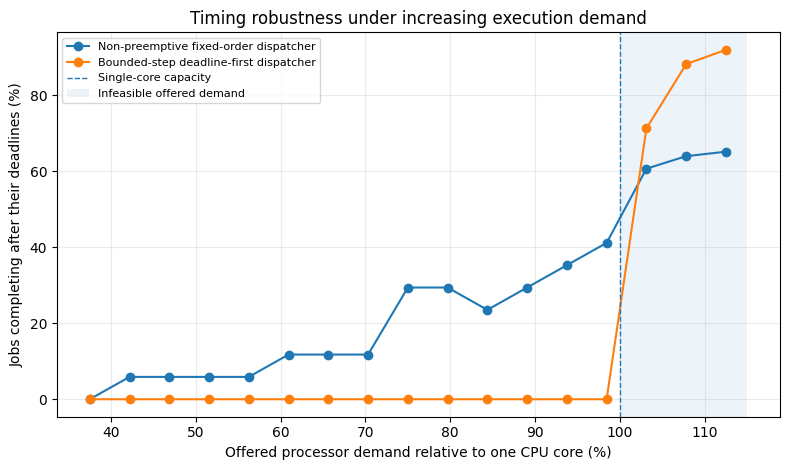

In [7]:
plot_scheduler(scheduler_results)
plt.show()

In [8]:
selected = scheduler_results.iloc[(scheduler_results.offered_demand_pct-90).abs().argsort()[:2]]
display(selected)
metrics, jobs = simulate_scheduler(1.45, "bounded_deadline_first")
print(metrics)
display(jobs.groupby("task").agg(jobs=("missed","size"), misses=("missed","sum"), p95_response_ms=("response_ms",lambda x:x.quantile(.95)), max_lateness_ms=("lateness_ms","max")))

,policy,load_scale,offered_demand_pct,jobs,misses,miss_rate,mean_response_ms,p95_response_ms,max_lateness_ms
23,bounded_deadline_first,1.425,89.0625,425,0,0.000000,24.394118,172.425,-14.80
22,blocking_fixed_order,1.425,89.0625,425,125,0.294118,37.639706,151.050,51.05


{'policy': 'bounded_deadline_first', 'load_scale': 1.45, 'offered_demand_pct': 90.625, 'jobs': 425, 'misses': 0, 'miss_rate': 0.0, 'mean_response_ms': 24.92941176470584, 'p95_response_ms': 175.44999999999936, 'max_lateness_ms': -14.74999999999909}


,jobs,misses,p95_response_ms,max_lateness_ms
task,,,,
inference,100,0,26.10,-23.90
sample,250,0,5.25,-14.75
telemetry,25,0,175.45,-24.55
watchdog,50,0,76.90,-23.10


### Analysis
A bounded service step reduces monopolisation, but it cannot create processor capacity. The model now counts each deadline miss once and preserves separate jobs. Challenge extensions include release jitter, a rare network stall, interrupt interference, fixed-priority preemptive scheduling, and a true preemptive EDF reference model.

---
## Exercise 27.3 - Agreement Analysis with a Transparent Pedagogical Dataset

The dataset below is intentionally synthetic. It demonstrates signed error, acceptance bands, and Bland-Altman-style limits of agreement. A genuine reproduction must replace the table with versioned raw simulator and hardware logs, plus firmware hash, board revision, compiler/toolchain versions, clock configuration, repetition policy, and measurement method.

In [9]:
paired = pedagogical_validation_data()
summary = validation_summary(paired)
display(paired)
display(summary)

,board,configuration,simulator_speedup,hardware_speedup,relative_error_pct,predeclared_limit_pct,data_origin
0,Arduino Mega 2560,cfg-01,7.2,7.19424,-0.08,0.1,pedagogical_synthetic_from_published_bounds
1,Arduino Mega 2560,cfg-02,10.4,10.40312,0.03,0.1,pedagogical_synthetic_from_published_bounds
2,Arduino Mega 2560,cfg-03,14.6,14.60876,0.06,0.1,pedagogical_synthetic_from_published_bounds
3,Arduino Mega 2560,cfg-04,18.1,18.09276,-0.04,0.1,pedagogical_synthetic_from_published_bounds
4,Arduino Mega 2560,cfg-05,20.8,20.81872,0.09,0.1,pedagogical_synthetic_from_published_bounds
5,Arduino Mega 2560,cfg-06,24.3,24.29757,-0.01,0.1,pedagogical_synthetic_from_published_bounds
6,Arduino Mega 2560,cfg-07,27.1,27.11355,0.05,0.1,pedagogical_synthetic_from_published_bounds
7,ESP32-C3,cfg-01,5.8,5.75070,-0.85,1.0,pedagogical_synthetic_from_published_bounds
8,ESP32-C3,cfg-02,8.9,8.93560,0.40,1.0,pedagogical_synthetic_from_published_bounds
9,ESP32-C3,cfg-03,11.4,11.37150,-0.25,1.0,pedagogical_synthetic_from_published_bounds


,board,n,mean_error_pct,std_error_pct,max_abs_error_pct,mean_difference,loa_low,loa_high,acceptance_limit_pct,passes_bound
0,Arduino Mega 2560,7,0.014286,0.060238,0.09,0.004103,-0.015402,0.023608,0.1,True
1,ESP32-C3,7,0.074286,0.654188,0.92,0.028766,-0.169435,0.226966,1.0,True


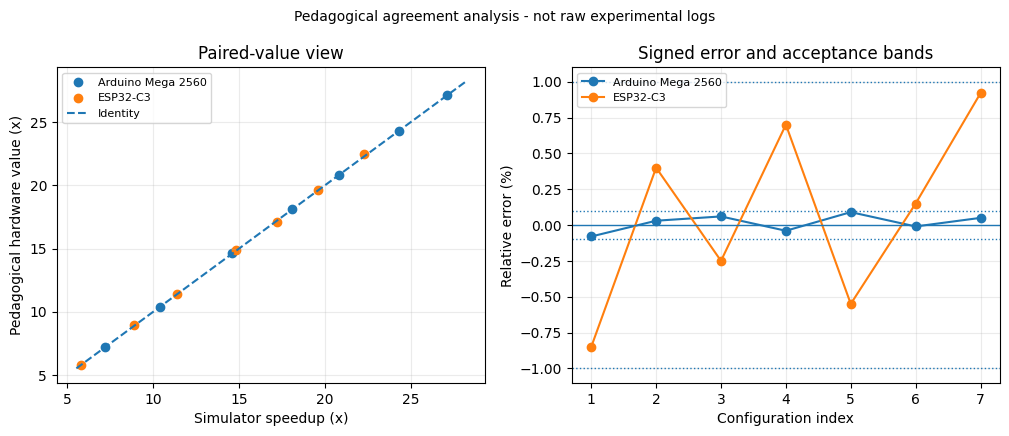

In [10]:
plot_validation(paired)
plt.show()

In [11]:
biased = paired.copy()
biased["hardware_speedup"] *= 1.05
biased["relative_error_pct"] = 100*(biased.hardware_speedup-biased.simulator_speedup)/biased.simulator_speedup
print("Correlation after a systematic 5% bias:", biased[["simulator_speedup","hardware_speedup"]].corr().iloc[0,1])
display(validation_summary(biased))

Correlation after a systematic 5% bias: 0.9999483509268381


,board,n,mean_error_pct,std_error_pct,max_abs_error_pct,mean_difference,loa_low,loa_high,acceptance_limit_pct,passes_bound
0,Arduino Mega 2560,7,5.015,0.063250,5.0945,0.879308,0.160829,1.597787,0.1,False
1,ESP32-C3,7,5.078,0.686897,5.9660,0.744490,0.032301,1.456678,1.0,False


### Analysis
High correlation does not establish agreement. For real repeated measurements, add uncertainty intervals, inspect run-to-run variation, and use Bland-Altman analysis or another method matched to the measurement scale. Passing a timing threshold says nothing about radio range, analogue accuracy, or energy.

---
## Exercise 27.4 - Quantized LUT Compilation and Pareto Analysis

Sweep table resolution `L` and bit depth `b`. The storage model reports both ideal packed storage and straightforward byte-aligned storage, making the 12-bit case explicit rather than silently treating it as 16 bits.

In [12]:
sweep = lut_sweep()
front = pareto_front(sweep)
display(sweep)
display(front)

,bits,levels,packed_table_bytes,aligned_table_bytes,metadata_bytes,packed_total_bytes,aligned_total_bytes,rmse,max_abs_error
0,8,8,8,8,16,24,24,0.078374,0.152365
1,8,16,16,16,16,32,32,0.021273,0.051750
2,8,32,32,32,16,48,48,0.005920,0.013762
3,8,64,64,64,16,80,80,0.002685,0.005039
4,8,128,128,128,16,144,144,0.002438,0.004485
5,8,256,256,256,16,272,272,0.002112,0.004381
6,12,8,12,16,16,28,32,0.078319,0.152041
7,12,16,24,32,16,40,48,0.019742,0.050077
8,12,32,48,64,16,64,80,0.004702,0.012424
9,12,64,96,128,16,112,144,0.001145,0.003083


,bits,levels,packed_table_bytes,aligned_table_bytes,metadata_bytes,packed_total_bytes,aligned_total_bytes,rmse,max_abs_error
0,8,8,8,8,16,24,24,0.078374,0.152365
1,12,8,12,16,16,28,32,0.078319,0.152041
2,8,16,16,16,16,32,32,0.021273,0.051750
3,12,16,24,32,16,40,48,0.019742,0.050077
4,8,32,32,32,16,48,48,0.005920,0.013762
5,12,32,48,64,16,64,80,0.004702,0.012424
6,8,64,64,64,16,80,80,0.002685,0.005039
7,12,64,96,128,16,112,144,0.001145,0.003083
8,12,128,192,256,16,208,272,0.000312,0.000838
9,16,128,256,256,16,272,272,0.000284,0.000752


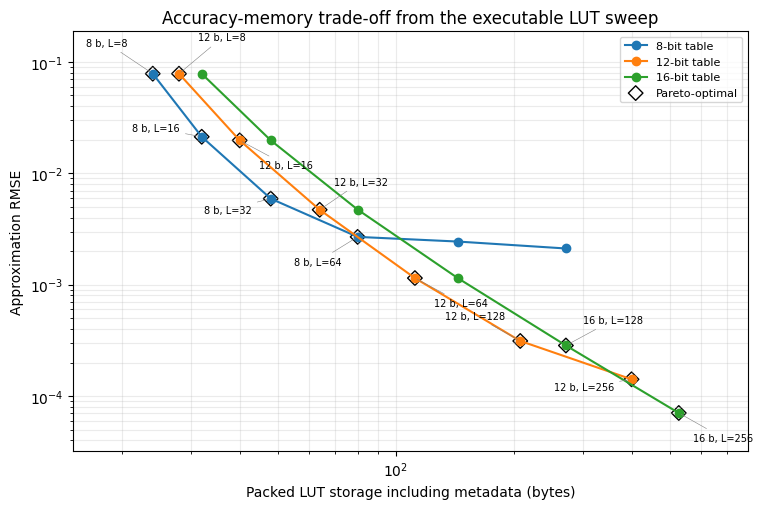

In [13]:
plot_lut(sweep)
plt.show()

In [14]:
# Export one Pareto-optimal 8-bit table as a compact, directly usable C header
# (16 bytes of metadata: xmin, inv_step, ymin, scale -- matching Eq. 27.x -- plus
# a linear-interpolation eval function), and confirm it round-trips.
choice = front[front.bits == 8].sort_values("rmse").iloc[0]
header_text = lut_header_text(int(choice.levels), int(choice.bits))
print(header_text)

#pragma once
#include <stdint.h>

#define CH27_LUT_LEVELS 64

// 16 bytes of metadata (4 x 32-bit float), matching Eq. (eq:lut-memory-packed):
static const float ch27_lut_xmin     = -1.0f;
static const float ch27_lut_inv_step = 31.5f;
static const float ch27_lut_ymin     = -1.14814802f;
static const float ch27_lut_scale    = 0.00900508253f;

static const uint8_t ch27_lut[CH27_LUT_LEVELS] = {
  10, 6, 3, 1, 0, 1, 3, 6, 10, 15, 20, 25, 29, 32, 35, 36, 37, 36, 34, 32, 30, 29, 28, 29, 31, 36, 44, 54, 67, 82, 100, 118, 137, 155, 173, 188, 201, 211, 219, 224, 226, 227, 226, 225, 223, 221, 219, 218, 219, 220, 223, 226, 230, 235, 240, 245, 249, 252, 254, 255, 254, 252, 249, 245
};

// Linear interpolation between the two neighbouring quantised entries.
static inline float ch27_lut_eval(float x) {
  float pos = (x - ch27_lut_xmin) * ch27_lut_inv_step;
  if (pos < 0.0f) pos = 0.0f;
  if (pos > (float)(CH27_LUT_LEVELS - 1)) pos = (float)(CH27_LUT_LEVELS - 1);
  int i0 = (int)pos;
  if (i0 > CH27_

---
## Practice Section Summary

| Exercise | Deployment question | Evidence produced |
|---|---|---|
| 27.1 | Does the platform fit with credible reserves and a plausible energy duty cycle? | Headroom matrix and scenario-based energy estimate |
| 27.2 | How do blocking and bounded-step dispatch affect jobs and deadlines? | Job-level response and miss metrics |
| 27.3 | What analysis is required to determine whether simulator-to-hardware agreement is adequate for a stated claim? | Worked synthetic example of paired-error analysis, acceptance thresholds, and bias detection |
| 27.4 | Which quantized representation lies on the Pareto frontier? | Multi-bit accuracy-memory sweep |

The notebook demonstrates methods. Hardware claims require raw measurements and complete provenance.